In [1]:
%env CUDA_VISIBLE_DEVICES=0

import glob, os
import torch, numpy as np

from pathlib import Path

from tqdm import tqdm
from diffusers import DDPMScheduler

import matplotlib.pyplot as plt
from torchvision.utils import make_grid

from einops import rearrange
from typing import Union, Callable, Optional, Sequence

import math
from time import time
import torch.nn as nn
from scipy.special import loggamma
from scipy.stats import linregress
from scipy.interpolate import make_smoothing_spline, splrep, splev

try:
    from src import Unet
    from stats_utils import sort_files, get_unet, get_metric_fn
except ModuleNotFoundError:
    import os; os.chdir("..")
    from src import Unet
    from stats_utils import sort_files, get_unet, get_metric_fn

env: CUDA_VISIBLE_DEVICES=0


/home/AchilliB/losing-dimensions/.venv/lib64/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import sys
print(sys.executable)

/home/AchilliB/losing-dimensions/.venv/bin/python3


In [3]:
def get_non_intersect(A, B):
    if len(A) == len(B): 
        #print('Both have equal size')
        return None
    
    ref_sizes = set([int(Path(f).name.split('.')[0]) for f in B])
    tar_sizes = set([int(Path(f).name.split('.')[0]) for f in A])
    
    result = []
    for size in ref_sizes:
        if size not in tar_sizes:
            result.append(size)
    return result

In [4]:
def get_evenly_spaced_indices(num_labels, num_ticks):
    """
    Returns indices that are evenly spaced visually, including the first and last indices.
    Parameters:
    -----------
    num_labels : int
        Total number of labels available.
    num_ticks : int
        Desired number of ticks (including the first and last) to show.
    """
    # Get the left extrem
    indices = [0]
    # Calculate the step size
    step = (num_labels - 1) / (num_ticks - 1)
    # Add intermediate indices
    for i in range(1, num_ticks - 1):
        indices.append(round(i * step))
    # Add the last index
    indices.append(num_labels - 1)
    return indices

In [5]:
def estimate_manifold_dim(
    singular_values: np.ndarray,
    c: float = 10.0,
    d_bar: int = 5
) -> int:
    """
    Estimates the intrinsic manifold dimension from a vector of singular values.
    Args:
        singular_values (np.ndarray): A NumPy array of singular values,
                                      sorted in descending order.
        
        c (float): The threshold multiplier. The algorithm looks for a curvature
                   that is 'c' times greater than the median curvature.
                   A value between 5 and 15 is typical.
                   
        d_bar (int): The number of initial singular values to discard. This helps
                     to ignore potential outliers or the initial gentle curve,
                     focusing the search on the main part of the spectrum.
    Returns:
        Optional[int]: The estimated intrinsic manifold dimension 'k'. Returns None
                       if no significant gap is found or if the input is too small.
    """
    if not isinstance(singular_values, np.ndarray):
        raise ValueError("Input singular_values must be a Numpy array.")

    d = singular_values.shape[-1]
    
    if d < d_bar + 3:
        print("Warning: Not enough singular values to compute dimension. Returning None.")
        return None

    svs_trimmed = singular_values[:, d_bar:]

    # The second derivative is approximated using the central difference formula:
    # f''(i) ≈ f(i+1) - 2f(i) + f(i-1)
    # np.diff(x, n=2) computes this efficiently.
    second_derivative = np.diff(svs_trimmed, n=2, axis=-1)

    # The algorithm uses the absolute value to turn the sharp drop into a positive spike.
    d2_svd = np.abs(second_derivative)

    m = np.median(d2_svd)

    spike_indices = []
    for d2 in d2_svd:
        indices = np.where(d2 > c * m)[0]
        if len(indices) > 0:
            spike_indices.append(indices)

    spike_indices = np.concatenate(spike_indices)
    
    if len(spike_indices) == 0:
        print(f"Warning: No cliff found with threshold c={c}. Returning dimension as total length.")
        return d # If no cliff, assume data fills the space.

    # The first index 'n' marks the beginning of the cliff.
    # We add 1 because the second derivative at index `i` corresponds to the
    # original point at `i+1`.
    n = spike_indices + 1
    k = n + d_bar
    return d - k, np.abs(np.diff(singular_values, n = 2, axis = -1))

In [6]:
def get_stats(folders, D: int = 3072, sample_size=-1):
    result = {'x': [], 'y': []}
    
    for folder in tqdm(folders):
        size = int(Path(folder).name.split('.')[0])
        result['x'].append(size)
        
        npz_files = os.path.join(folder, "*.npz")
        npz_files = glob.glob(npz_files)

        if sample_size is not None and sample_size != -1:
            npz_files = npz_files[:sample_size]
        
        y = []
        for f in npz_files:
            npz = np.load(f, allow_pickle=True)
            y.append(npz['singular'])
        
        if len(y) > 0:
            y = np.stack(y)
        result['y'].append(y)
    return result

In [12]:
def get_stats_single(folder, size=100, sample_size=-1):
    result = {"x": [size], "y": []}

    npz_files = sorted(
        glob.glob(os.path.join(folder, "*.npz")),
        key=lambda path: int(Path(path).stem)
    )

    if sample_size is not None and sample_size != -1:
        npz_files = npz_files[:sample_size]

    y = []
    for file in tqdm(npz_files):
        with np.load(file, allow_pickle=True) as npz:
            y.append(npz["singular"])

    if y:
        y = np.stack(y)

    result["y"].append(y)
    return result

In [7]:
def compute_line(results, stats, sample_type: str, D: int, normalize: bool = False, k: int = 5, sample_size: int = -1):
    xs = stats['x']
    ys = stats['y']

    for x, y in zip(xs, ys):
        if sample_size is not None and sample_size != -1:
            y = y[:sample_size]

        print(x, len(y))
        if normalize:
            y = y / np.amax(y, axis=-1, keepdims=True)

        y_avg = y.mean(0)
        y_std = y.std(0)

        y_ub = y_avg + y_std
        y_lb = y_avg - y_std
        y_lb = np.clip(y_lb, a_min = 0, a_max = None)
        results[x][sample_type] = dict(
            original_y = y,
            y = y_avg, 
            lb = y_lb,
            ub = y_ub,
            y_k = y[:, :k],
            d = D
        )

    return results

In [8]:
labels = {'green': 'Spurious', 'red': 'Memorized', 'blue': 'Generalized', 'orange': 'Data'}

In [32]:
# root_folder = 'celebahq64'
# dim = 64
# t = 2
# k_mult = 4

# if root_folder == 'cifar10':
#     D = 3 * 32 * 32
# elif root_folder == 'church64' or root_folder == 'celebahq64':
#     D = 3 * 64 * 64
# else:
#     D = 28 * 28

# target_dir = f"./target-images/{root_folder}/"
# data_files = glob.glob(os.path.join(f'new_ckpts/{root_folder}-unet{dim}/', "*.pt"))

# stat_dir = f"svds/{root_folder}-unet{dim}/t={t}-k={k_mult}/"
# data_stats_folders = glob.glob(os.path.join(stat_dir, "data/*"))

# print("Data:", get_non_intersect(data_stats_folders, data_files))
# data_stats = get_stats(sort_files(data_stats_folders), D = D)

Data: []


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 38/38 [06:43<00:00, 10.62s/it]


In [15]:
data_stats = get_stats_single(
    "results_test/cifar10_n100/svd",
    size=100
)

100%|██████████| 5/5 [00:00<00:00, 1254.28it/s]


In [16]:
all_xs = data_stats['x']
all_xs.sort()
print(all_xs)

normalize_svs = False
results = {size: {} for size in all_xs}

print('\nData')
results = compute_line(results, data_stats, 'data', D, normalize=normalize_svs, sample_size=-1)

[100]

Data


NameError: name 'D' is not defined

# Plotting Average Singular Values (But Ignoring the First One)

In [ ]:
k = 5
xs = None
for size in results.keys():    
    fig, ax = plt.subplots(1, 1, figsize=(8, 6), sharex=True, dpi=100, constrained_layout=True)
    ax.set_title(f'K = {size}', fontsize=18)

    if results[size].get('data') is None: continue

    d_y = results[size]['data']['y'][k:]    
    d_lb = results[size]['data']['lb'][k:]
    d_ub = results[size]['data']['ub'][k:]

    xs = np.arange(D - d_y.shape[-1] + 1, D + 1) if xs is None else xs

    ax.plot(xs, d_y, color='orange', label=labels['orange'])
    ax.fill_between(xs, d_ub, d_lb, color='orange', alpha=0.2)

    plt.grid(True, linestyle='--')
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.legend(fontsize=16)
    plt.ylabel('Singular Value', fontsize=18, labelpad=10)
    plt.xlabel('Ranking', fontsize=18, labelpad=10)

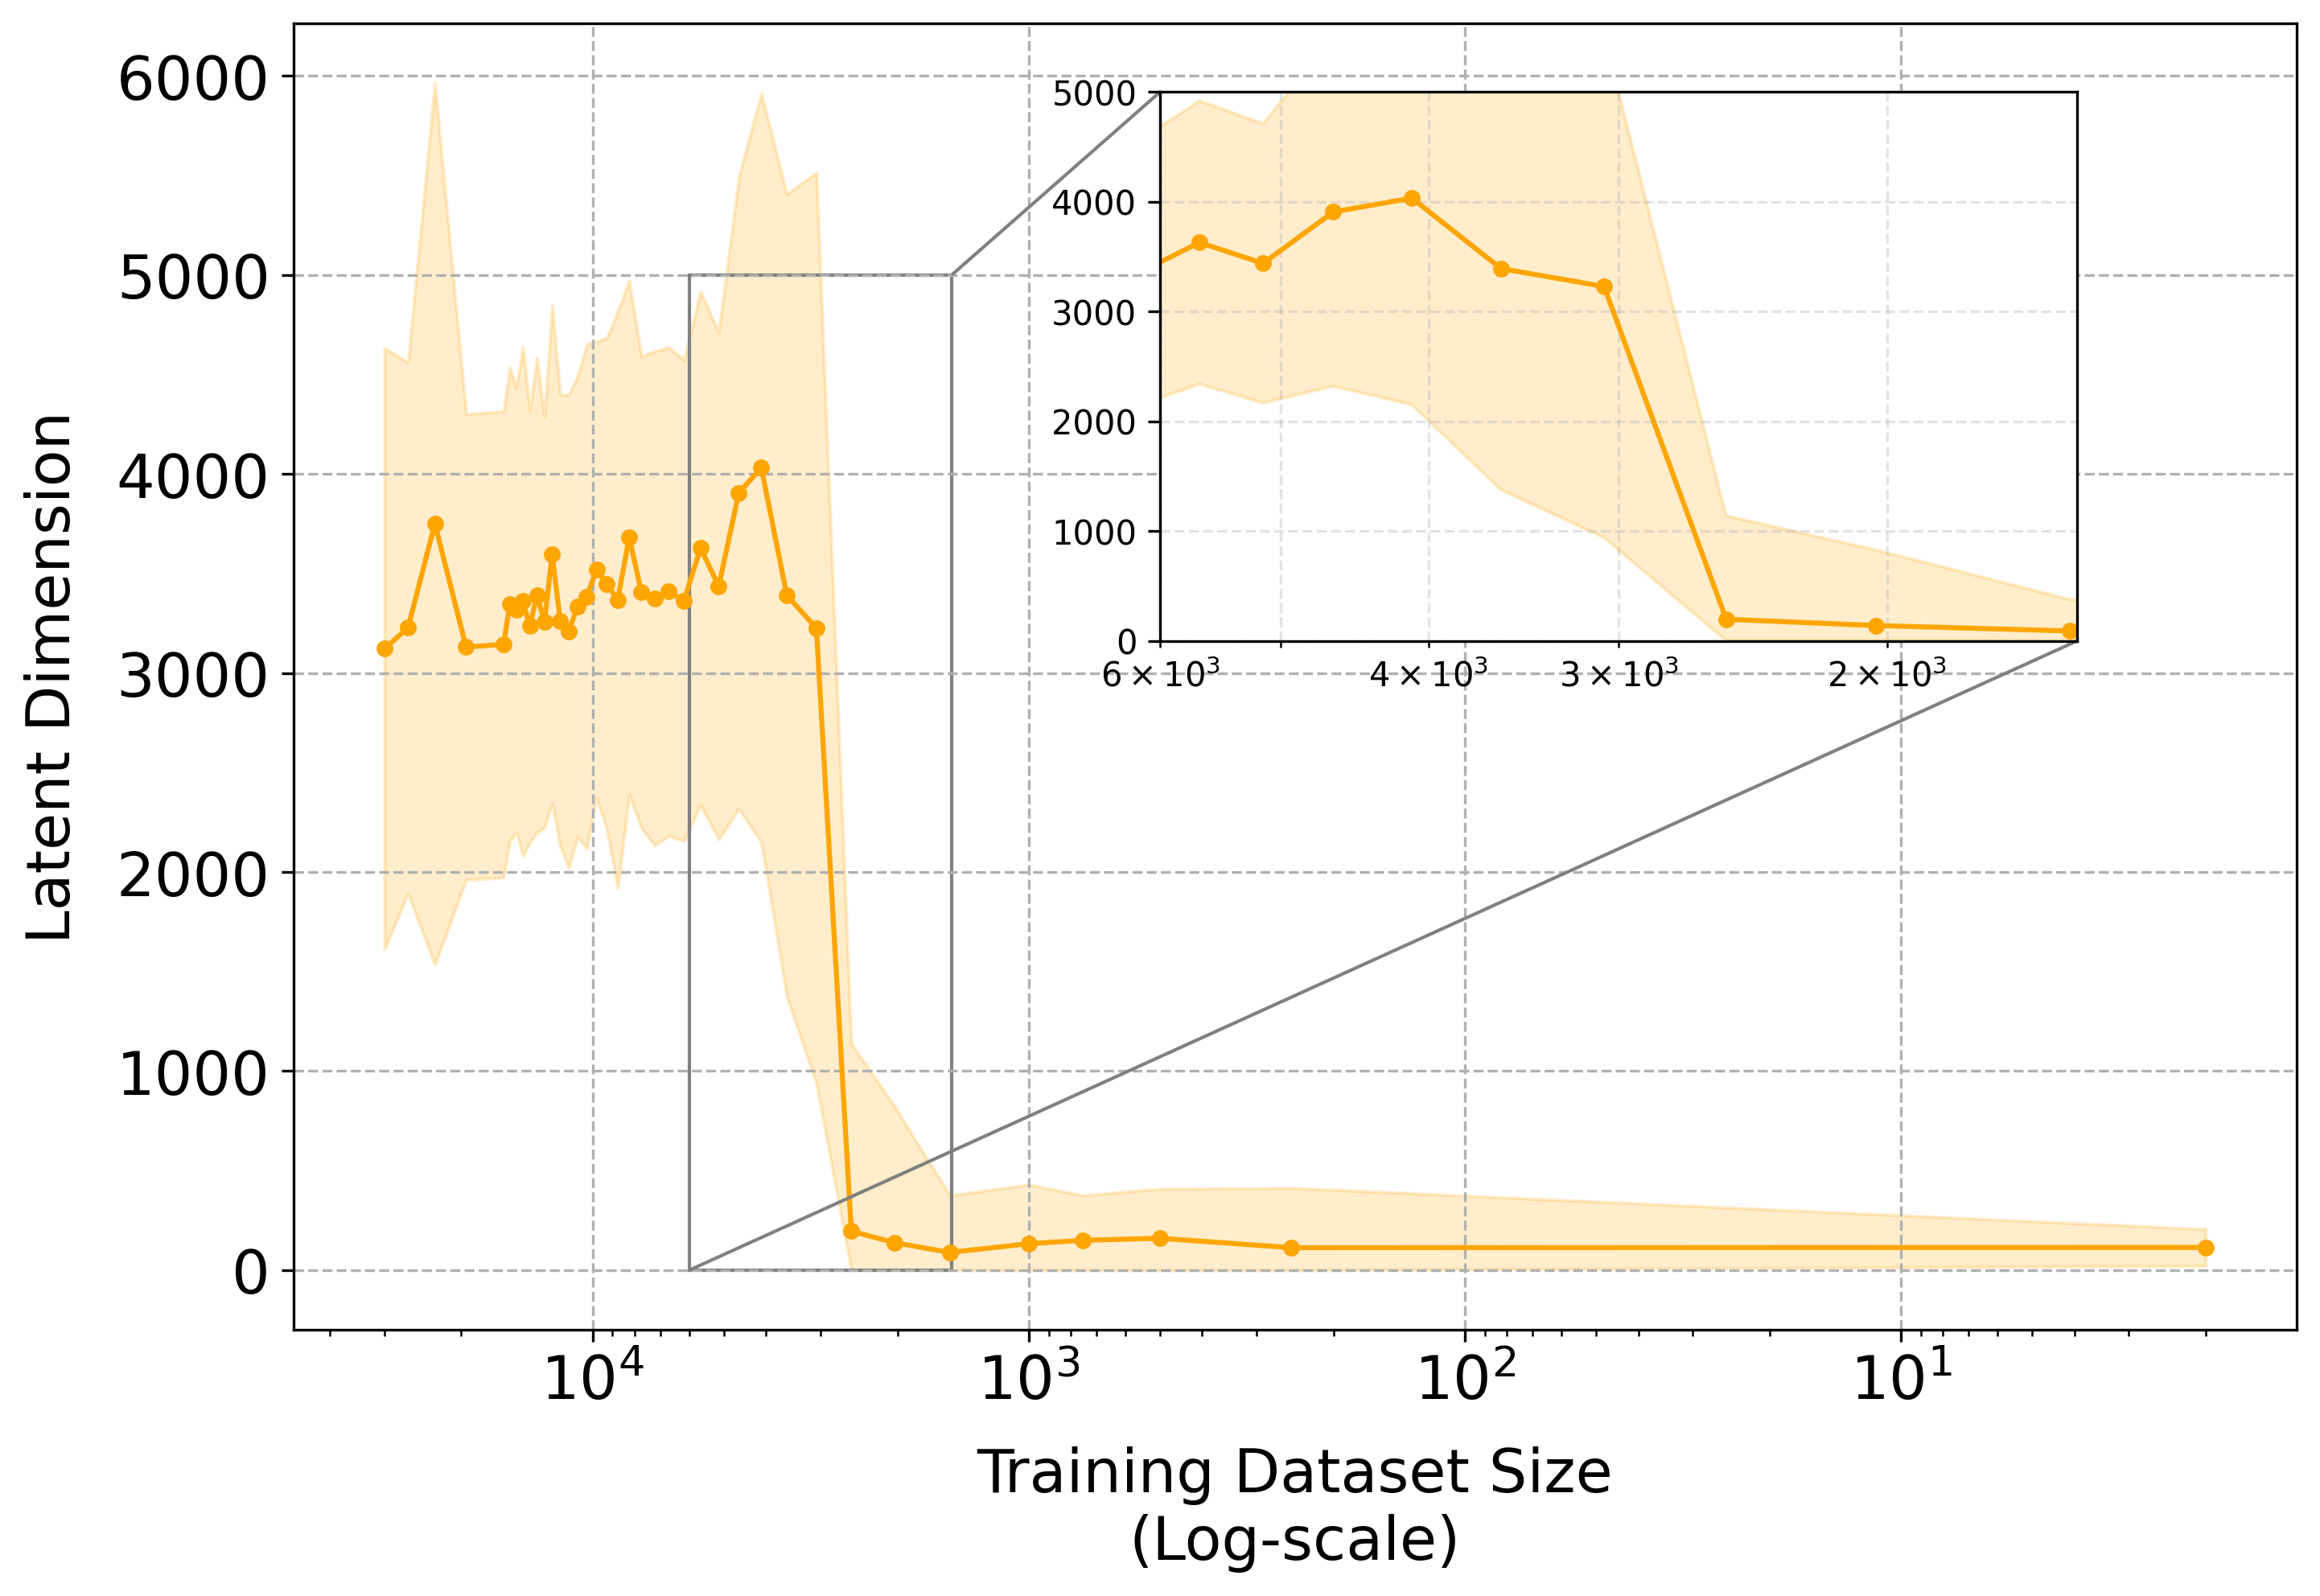

In [34]:
import matplotlib.ticker as ticker
# For creating the indicator box for the inset
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
from matplotlib.ticker import FuncFormatter, LogLocator, MaxNLocator

xs, ys, lbs, ubs = [], [], [], []
d2_svs = []

# cifar10: d_bar = 1000 c=10 t=15
# mnist: d_bar = 100 c=15
# church: d_bar = 2200, c=10

if root_folder == 'church64':
    d_bar = 2_000
    est_c = 20

elif root_folder == 'celebahq64':
    d_bar = 1_500
    est_c = 10
    
elif root_folder == 'cifar10':
    d_bar = 1000
    est_c = 10

elif root_folder == 'mnist':
    d_bar = 100
    est_c = 20
    
elif root_folder == 'fmnist':
    d_bar = 200
    est_c = 15

else:
    raise NotImplementedError

for size in results.keys():    
    if results[size].get('data') is None: continue
    xs.append(size)
    d_y = results[size]['data']['original_y']
        
    d_y, d2_sv = estimate_manifold_dim(d_y, d_bar=d_bar, c=est_c)

    d_err = d_y.std(0)
    d_mu = d_y.mean(0)

    ys.append(d_mu)
    d2_svs.append(d2_sv)
    lbs.append(np.clip(d_mu - d_err, a_min=0, a_max=None))
    ubs.append(d_mu + d_err)

fig, ax = plt.subplots(1, 1, figsize=(9.5, 6.5), dpi=300, sharex=True, constrained_layout=True)
indices = get_evenly_spaced_indices(len(xs), 10)

xs = np.array(xs)

ax.plot(xs, ys, color='orange', marker='o', markersize=4)
ax.fill_between(xs, ubs, lbs, color='orange', alpha=0.2)

plt.grid(True, linestyle='--')
plt.yticks(fontsize=18)
plt.xticks(fontsize=18)

ax.set_xscale('log')

if root_folder == 'church64':
    ax_inset = fig.add_axes([0.55, 0.6, 0.4, 0.35])
else:
    ax_inset = fig.add_axes([0.5, 0.6, 0.4, 0.35]) # [left, bottom, width, height]

ax_inset.plot(xs, ys, marker='o', color='orange', markersize=4)
ax_inset.fill_between(xs, ubs, lbs, color='orange', alpha=0.2)
ax_inset.set_xscale('log')

if root_folder == 'cifar10':
    ax.annotate(
        'Drop in Dimension', 
        xy=(3000, 600), 
        xytext=(100, 300),
        arrowprops=dict(facecolor='black', shrink=0.05, width=0.2, headwidth=5),
        fontsize=14
    )
    ax_inset.set_xlim(1500, 8000) 
    ax_inset.set_ylim(0, 1200)

elif root_folder == 'church64':
    ax_inset.set_xlim(1500, 8000) 
    ax_inset.set_ylim(0, 3500)
    #ax_inset.xaxis.set_major_locator(MaxNLocator(2))

elif root_folder == 'celebahq64':
    ax_inset.set_xlim(1500, 6000) 
    ax_inset.set_ylim(0, 5000)
    #ax_inset.xaxis.set_major_locator(MaxNLocator(6))    

elif root_folder == 'fmnist':
    ax_inset.set_xlim(1500, 8000) 
    ax_inset.set_ylim(0, 350)
    ax_inset.xaxis.set_major_locator(MaxNLocator(2))

elif root_folder == 'mnist':
    ax_inset.set_xlim(1500, 10000) 
    ax_inset.set_ylim(0, 100)
    ax_inset.xaxis.set_major_locator(MaxNLocator(2))

#ax_inset.set_title('High-Resolution View')
ax_inset.grid(True, which='both', linestyle='--', alpha=0.35)
ax_inset.invert_xaxis()
mark_inset(ax, ax_inset, loc1=2, loc2=4, fc="none", ec="0.5")

#plt.legend(fontsize=16)
ax.set_ylabel('Latent Dimension', fontsize=18, labelpad=10)
ax.set_xlabel('Training Dataset Size\n(Log-scale)', fontsize=18, labelpad=10)

# Invert the x-axis
ax.invert_xaxis()
plt.show()

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8.5, 6), dpi=300, sharex=True, constrained_layout=True)
indices = get_evenly_spaced_indices(len(xs), 10)

xs = np.array(xs).astype('str')

ax.plot(xs, ys, color='orange', marker='o')
ax.fill_between(xs, ubs, lbs, color='orange', alpha=0.2)

my_ticks = list(xs[indices])
ax.set_xticks(ticks=indices, labels=my_ticks, fontsize=18, rotation=50)

#ax.set_xticks(xs[indices])
#ax.set_xticklabels(xs[indices])

plt.grid(True, linestyle='--')
plt.yticks(fontsize=18)
plt.xticks(fontsize=18)

#plt.legend(fontsize=16)
ax.set_ylabel('Latent Dimension', fontsize=18, labelpad=10)
ax.set_xlabel('Training Data Size', fontsize=18, labelpad=10)

# Invert the x-axis
ax.invert_xaxis()

plt.show()

In [20]:
xs = None
k = 5
fig, axs = plt.subplots(7, 6, 
                        figsize=(36 / 1.075, 24), dpi=300, sharex=False, constrained_layout=True, 
                        gridspec_kw={'hspace': 0.075}
                       )

keys = list(results.keys())

# empty column first row
for i in range(6):
    if i >= 2:
        axs[0][i].axis('off')
        continue
    
    size = keys[i]
    ax = axs[0][i]

    if results[size].get('data') is None: continue
    ax.set_title(f'K = {size}', fontsize=18)
    
    d_y = results[size]['data']['y'][k:]    
    d_lb = results[size]['data']['lb'][k:]
    d_ub = results[size]['data']['ub'][k:]

    xs = np.arange(D - d_y.shape[-1] + 1, D + 1) if xs is None else xs

    ax.plot(xs, d_y, color='orange', label=labels['orange'])
    ax.fill_between(xs, d_ub, d_lb, color='orange', alpha=0.2)

    ax.grid(True, linestyle='--')
    ax.tick_params(axis='y', labelsize=18)
    ax.tick_params(axis='x', labelsize=18)

    
for j, size in enumerate(keys[2:]):       
    col = j % 6 
    row = 1 if j < 6 else 2 if j < 12 else 3 if j < 18 else 4 if j < 24 else 5 if j < 30 else 6

    ax = axs[row][col]
    ax.set_title(f'K = {size}', fontsize=18)

    if results[size].get('data') is None: continue

    d_y = results[size]['data']['y'][k:]    
    d_lb = results[size]['data']['lb'][k:]
    d_ub = results[size]['data']['ub'][k:]

    xs = np.arange(D - d_y.shape[-1] + 1, D + 1) if xs is None else xs

    ax.plot(xs, d_y, color='orange', label=labels['orange'])
    ax.fill_between(xs, d_ub, d_lb, color='orange', alpha=0.2)

    ax.grid(True, linestyle='--')
    ax.tick_params(axis='y', labelsize=18)
    ax.tick_params(axis='x', labelsize=18)

fig.supxlabel("Ordering of Singular Value", fontsize=23, y=-0.025)
fig.supylabel("Singular Value", fontsize=23)
plt.show()

KeyboardInterrupt: 

In [ ]:
second_derivs = d2_svs[-1].mean(0)
#second_derivs = second_derivs / np.max(second_derivs)

fig, ax = plt.subplots(1, 1, figsize=(9.5, 6.5), dpi=300, sharex=True, constrained_layout=True)
indices = get_evenly_spaced_indices(len(xs), 10)

ax.plot(second_derivs[10:], color='Red', alpha=1.)
ax.axvline(D - d_bar, linestyle='--', color='black')
ax.grid(True, linestyle='--')

ax.set_ylabel('Average Absolute Second Derivative', fontsize=18, labelpad=10)
ax.set_xlabel('Ordering of Singular Value', fontsize=18, labelpad=10)
ax.tick_params(axis='y', labelsize=18)
ax.tick_params(axis='x', labelsize=18)
plt.show()

In [ ]:
def plot_individual(ax, y, cmap, title='', log_scale=False, legend=False):
    if title is not None:
        ax.set_title(title, fontsize=18)

    size = len(y)
    norm = mcolors.Normalize(vmin=0, vmax=size - 1)

    for i, arr in enumerate(y):
        if log_scale:
            arr = np.log(arr)
            
        color = cmap(norm(i))

        if i == 0:
            ax.plot(arr, color = color, label='Training Data', linewidth=2)
        else:
            ax.plot(arr, color = color, linewidth=2)

    ax.set_ylabel('Average Singular Value', fontsize=18, labelpad=10)
    ax.set_xlabel('Ordering of Singular Value', fontsize=18, labelpad=10)
    plt.xticks(fontsize=18.5); plt.yticks(fontsize=20);
    ax.grid(True, linestyle='--')

    if legend:
        ax.legend(fontsize=20)
    
    return ax, norm

In [ ]:
import matplotlib.colors as mcolors

k = 5

d_y = [];

for size in results.keys():    
    if results[size].get('data') is None: continue
    d_y.append(results[size]['data']['y'][k:])

In [ ]:
log_scale = False

#orange_cmap = plt.get_cmap('Oranges_r')
cmap_name = 'rainbow'
cmap = plt.get_cmap(f'{cmap_name}')

fig, ax = plt.subplots(figsize=(8, 6), dpi=300, constrained_layout=True)
ax, norm = plot_individual(ax, d_y, cmap, '', log_scale=log_scale, legend=False)

cmap_r = plt.get_cmap(f'{cmap_name}' + '_r')

sm = plt.cm.ScalarMappable(cmap=cmap_r, norm=norm)
#cbar = fig.colorbar(sm, ax=ax, shrink=1, pad=0.025)
#cbar.set_ticks([])
#cbar.set_label('Training Data', fontsize=20)
#cbar.set_ticks([0, len(d_y) - 1])
#cbar.set_ticklabels(['Large K', 'Small K'], fontsize=16)
plt.show()

In [ ]:
log_scale = False

orange_cmap = plt.get_cmap('Oranges_r')

fig, ax = plt.subplots(figsize=(12, 8), dpi=300, constrained_layout=True)
ax, norm = plot_individual(ax, d_y, orange_cmap, '', log_scale=log_scale)

orange_cmap_r = plt.get_cmap('Oranges')

sm = plt.cm.ScalarMappable(cmap=orange_cmap_r, norm=norm)
cbar = fig.colorbar(sm, ax=ax, shrink=1, pad=0.025)
cbar.set_ticks([0, len(d_y) - 1])
cbar.set_ticklabels(['Large Size', 'Small Size'], fontsize=16)

#plt.savefig(f'./svds/{root_folder}/t={t}-k={k_mult}/Generalized.png', dpi=100)
plt.show()